# Laboratório 06 Tratamento de Dados Raros e Alta Cardinalidade

**Disciplina:** Extração e Preparação de Dados (IBM8915)  
**Professor:** Luís Aramis

---

## 🎯 Objetivo

Compreender o impacto negativo da **alta cardinalidade** (o fenômeno da _cauda longa_) no desempenho de modelos analíticos. Você aprenderá a:

1. **Diagnosticar** a distribuição de frequência de variáveis categóricas.
2. **Decidir** um limiar de corte adequado ao contexto de negócio.
3. **Aplicar** técnicas do Pandas para agrupar categorias raras.

---

### 🗺️ Roteiro da Aula

| Parte | Tipo | Tempo estimado |
|---|---|---|
| **Parte 1** | Exemplo Guiado (Descoberta) | ~10 min |
| **Parte 2** | Exercício Prático | ~10 min |
| **Parte 3** | Desafio para Casa (Pipeline Completo) | ~30 min |

In [1]:
# Setup inicial — execute esta célula antes de tudo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


---

## Parte 1: Exemplo Guiado — O Problema da Cauda Longa

Variáveis categóricas como `Cidade`, `Profissão` ou `Marca` costumam ter um comportamento típico: **poucos valores dominam** e **muitos valores aparecem raramente** (a chamada *cauda longa*).

Se treinarmos um modelo de Machine Learning com esses dados raros, ele irá **memorizar ruído** (overfitting) em vez de aprender padrões reais. A solução é o **Binning Categórico**: agrupar tudo que for raro na categoria `'Outros'`.

---

### 🔎 Passo 1 — Explore antes de rodar

Abaixo, criamos um dataset de 1.000 clientes com a coluna `Cidade`. Antes de executar qualquer célula, responda:

> **📝 Quantas cidades únicas você espera encontrar? Quais cidades acha que irão dominar os dados?**
>
> Sua hipótese: Esperamos encontrar sete cidades raras e achamos que São Paulo, Rio de Janeiro e Belo Horizonte iram dominar.

Agora execute a célula abaixo e veja o dataset.

In [ ]:
# Criando o dataset de cidades com alta cardinalidade
np.random.seed(42)
cidades_comuns = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte']
cidades_raras  = ['Cabo Frio', 'Itu', 'Bauru', 'Gramado', 'Ouro Preto', 'Ilhéus', 'Picos']

amostra_cidades = np.random.choice(cidades_comuns, 950, p=[0.6, 0.3, 0.1]).tolist()
amostra_cidades.extend(np.random.choice(cidades_raras, 50))

df_exemplo = pd.DataFrame({'ID_Cliente': range(1, 1001), 'Cidade': amostra_cidades})

print(f"Total de linhas: {len(df_exemplo)}")
print(f"Cidades únicas: {df_exemplo['Cidade'].nunique()}")
df_exemplo.head()

Total de linhas: 1000
Cidades únicas: 10


,ID_Cliente,Cidade
0,1,São Paulo
1,2,Belo Horizonte
2,3,Rio de Janeiro
3,4,São Paulo
4,5,São Paulo


### 🔎 Passo 2 — Visualize a distribuição

A forma mais rápida de enxergar a *cauda longa* é com um gráfico de barras. Execute e observe:

> **📝 O gráfico evidenciou o que você esperava na sua hipótese? O que você percebe sobre a diferença de proporção entre as cidades comuns e raras?**
>
> Sua resposta: Observamos que elas sao mais frequentes, comparado as outras.

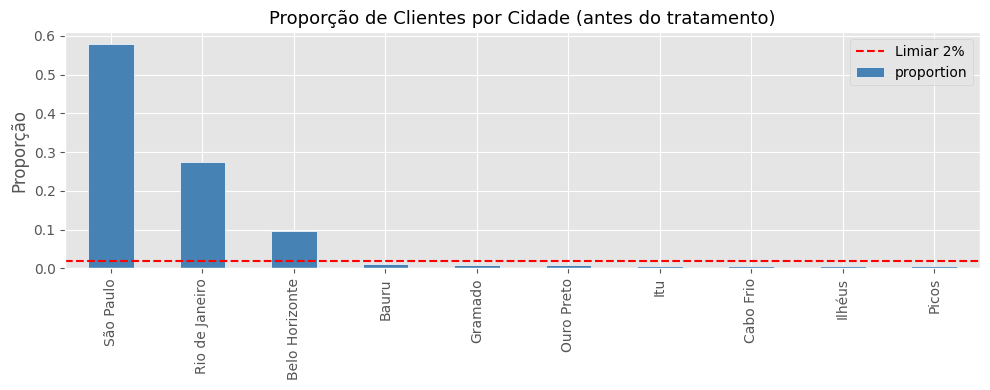


--- Proporção Original ---
Cidade
São Paulo         0.580
Rio de Janeiro    0.274
Belo Horizonte    0.096
Bauru             0.010
Gramado           0.008
Ouro Preto        0.008
Itu               0.007
Cabo Frio         0.006
Ilhéus            0.006
Picos             0.005


In [4]:
frequencias = df_exemplo['Cidade'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(10, 4))
frequencias.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(0.02, color='red', linestyle='--', linewidth=1.5, label='Limiar 2%')
ax.set_title('Proporção de Clientes por Cidade (antes do tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Proporção Original ---")
print(frequencias.to_string())

### 🔎 Passo 3 — Aplique a transformação

A linha vermelha tracejada no gráfico representa nosso **limiar de negócio**: qualquer cidade que aparecer em menos de 2% da base será agrupada como `'Outros'`. Execute e compare com o gráfico anterior.

> Sua resposta: A cidade que deve ser agrupada é Belo Horizonte.

Cidades que serão agrupadas em 'Outros': [np.str_('Bauru'), np.str_('Gramado'), np.str_('Ouro Preto'), np.str_('Itu'), np.str_('Cabo Frio'), np.str_('Ilhéus'), np.str_('Picos')]


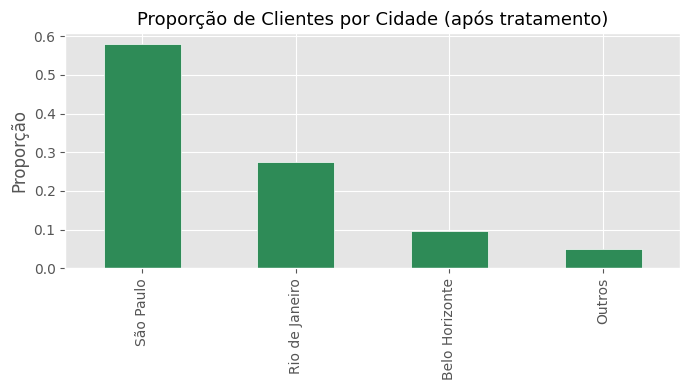


--- Proporção Após Tratamento ---
Cidade
São Paulo         0.580
Rio de Janeiro    0.274
Belo Horizonte    0.096
Outros            0.050


In [5]:
# Definindo o limiar
limite = 0.02
cidades_para_agrupar = frequencias[frequencias < limite].index

print(f"Cidades que serão agrupadas em 'Outros': {list(cidades_para_agrupar)}")

# Aplicando a transformação com .loc e .isin()
df_exemplo.loc[df_exemplo['Cidade'].isin(cidades_para_agrupar), 'Cidade'] = 'Outros'

# Visualização após tratamento
freq_apos = df_exemplo['Cidade'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(7, 4))
freq_apos.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Proporção de Clientes por Cidade (após tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print("\n--- Proporção Após Tratamento ---")
print(freq_apos.to_string())

### 💬 Reflexão — Parte 1

> **O que aconteceria com um modelo de ML se você tivesse treinado com as 10 cidades originais em vez das 4 categorias limpas?**  
> Pense especificamente em: *quantidade de colunas geradas pelo One-Hot Encoding* e *frequência de cada categoria no treino vs. teste*.
>
> Sua resposta: Teria muitos ruidos, o que poderia comprometer a analise.

---

## Parte 2: Exercício Prático — Mão na Massa

Você extraiu um banco de dados de currículos. A coluna `Profissao` foi preenchida **manualmente** pelos usuários, gerando variações e erros típicos de dados do mundo real.

**Contexto:** O time de RH quer usar esses dados para treinar um modelo de triagem. Mas com tantas variações raras, o modelo irá decorar profissões que aparecem 1 ou 2 vezes, sem poder generalizá-las.

---

### 📝 Formule sua hipótese antes de começar

> Com um limiar de **3% (0.03)**, quantas profissões você acha que sobrarão após o tratamento? (Considere que há 3 profissões comuns e 8 raras)
>
> Minha estimativa: 3 — Justificativa: Pois apresenta 3%.

Execute a célula abaixo para gerar os dados e depois escreva sua solução.

In [2]:
# NÃO ALTERE ESTE CÓDIGO — Geração do cenário do exercício
profissoes_comuns = ['Engenheiro de Dados', 'Cientista de Dados', 'Analista de BI']
profissoes_raras  = ['Cientista de Dados Junior', 'Eng. de Dados', 'Programador',
                     'Estatístico', 'Matemático', 'Físico', 'Estagiário', 'Desenvolvedor Python']

amostra_profissoes = np.random.choice(profissoes_comuns, 400).tolist()
amostra_profissoes.extend(np.random.choice(profissoes_raras, 60))


df_rh = pd.DataFrame({'ID_Candidato': range(1, 461), 'Profissao': amostra_profissoes})

print(f"Total de candidatos: {len(df_rh)}")
print(f"Profissões únicas antes do tratamento: {df_rh['Profissao'].nunique()}")
df_rh.head()


Total de candidatos: 460
Profissões únicas antes do tratamento: 11


,ID_Candidato,Profissao
0,1,Cientista de Dados
1,2,Cientista de Dados
2,3,Cientista de Dados
3,4,Engenheiro de Dados
4,5,Analista de BI


Profissoes que serão agrupadas em 'Outros': [np.str_('Físico'), np.str_('Matemático'), np.str_('Eng. de Dados'), np.str_('Estatístico'), np.str_('Programador'), np.str_('Desenvolvedor Python'), np.str_('Estagiário'), np.str_('Cientista de Dados Junior')]


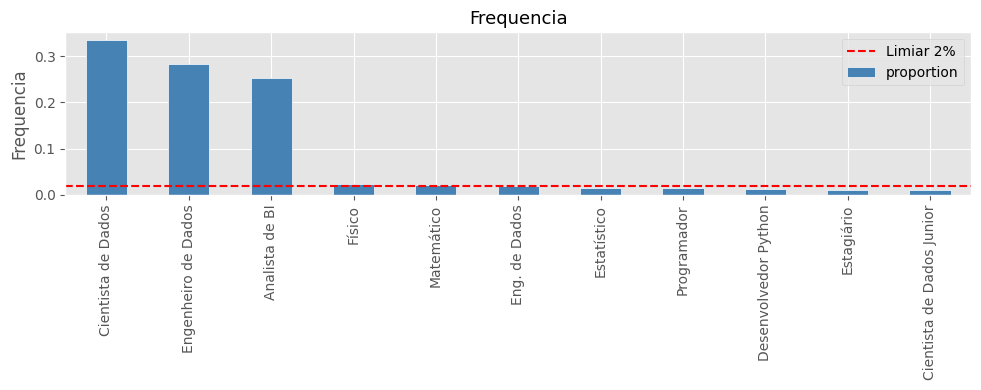


--- Proporção Original ---
Profissao
Cientista de Dados           0.334783
Engenheiro de Dados          0.282609
Analista de BI               0.252174
Físico                       0.023913
Matemático                   0.021739
Eng. de Dados                0.019565
Estatístico                  0.015217
Programador                  0.015217
Desenvolvedor Python         0.013043
Estagiário                   0.010870
Cientista de Dados Junior    0.010870


In [4]:
# ✍️ ESCREVA SEU CÓDIGO AQUI

# Passo 1: Calcule as frequências relativas da coluna 'Profissao'
frequencias = df_rh['Profissao'].value_counts(normalize=True)

limite = 0.03
profissao_para_agrupar = frequencias[frequencias < limite].index
print(f"Profissoes que serão agrupadas em 'Outros': {list(profissao_para_agrupar)}")


fig, ax = plt.subplots(figsize=(10, 4))
frequencias.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(0.02, color='red', linestyle='--', linewidth=1.5, label='Limiar 2%')
ax.set_title('Frequencia', fontsize=13)
ax.set_ylabel('Frequencia')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show() 

print("\n--- Proporção Original ---")
print(frequencias.to_string())



Profissoes que serão agrupadas em 'Outros': [np.str_('Físico'), np.str_('Matemático'), np.str_('Eng. de Dados'), np.str_('Estatístico'), np.str_('Programador'), np.str_('Desenvolvedor Python'), np.str_('Estagiário'), np.str_('Cientista de Dados Junior')]


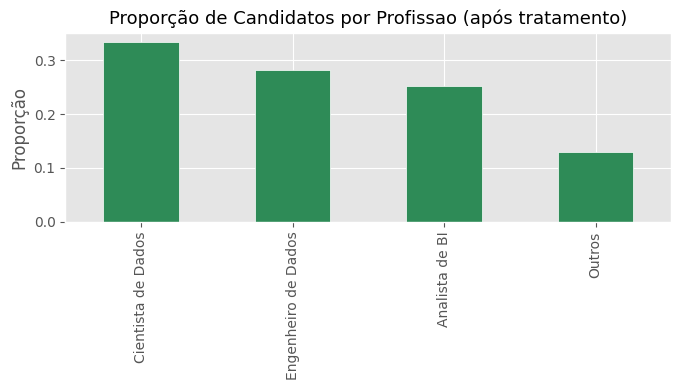


--- Proporção Após Tratamento ---
Profissao
Cientista de Dados     0.334783
Engenheiro de Dados    0.282609
Analista de BI         0.252174
Outros                 0.130435


In [5]:

# Passo 2: Isole o índice das profissões com frequência < 0.03
# df_exemplo_outros = pd.DataFrame({'ID_Candidato': range(1, 460), 'Profissao': amostra_profissoes})
limite = 0.03
profissao_para_agrupar = frequencias[frequencias < limite].index

print(f"Profissoes que serão agrupadas em 'Outros': {list(profissao_para_agrupar)}")

df_rh.loc[df_rh['Profissao'].isin(profissao_para_agrupar), 'Profissao'] = 'Outros'
freq_apos = df_rh['Profissao'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(7, 4))
freq_apos.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Proporção de Candidatos por Profissao (após tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print("\n--- Proporção Após Tratamento ---")
print(freq_apos.to_string())


In [6]:

# Passo 3: Substitua os valores raros por 'Outros' no df_rh
# Dica: use .loc com .isin()
df_rh.loc[df_rh['Profissao'].isin(profissao_para_agrupar), 'Profissao'] = 'Outros'

# Passo 4: Imprima o value_counts() final
print(df_rh['Profissao'].value_counts())
print(df_rh['Profissao'].value_counts(normalize=True))

Profissao
Cientista de Dados     154
Engenheiro de Dados    130
Analista de BI         116
Outros                  60
Name: count, dtype: int64
Profissao
Cientista de Dados     0.334783
Engenheiro de Dados    0.282609
Analista de BI         0.252174
Outros                 0.130435
Name: proportion, dtype: float64


In [7]:
# ✅ CÉLULA DE VERIFICAÇÃO — Execute após completar o exercício
try:
    n_categorias = df_rh['Profissao'].nunique()
    assert n_categorias <= 4, (
        f"❌ Ainda há {n_categorias} categorias únicas. "
        "Verifique se o limiar de 0.03 foi aplicado corretamente."
    )
    assert 'Outros' in df_rh['Profissao'].values, (
        "❌ A categoria 'Outros' não foi encontrada. "
        "Certifique-se de usar exatamente a string 'Outros'."
    )
    print(f"✅ Parabéns! Cardinalidade reduzida para {n_categorias} categorias.")
    print("   O DataFrame df_rh está pronto para o One-Hot Encoding do Lab 07!")
except AssertionError as e:
    print(e)

✅ Parabéns! Cardinalidade reduzida para 4 categorias.
   O DataFrame df_rh está pronto para o One-Hot Encoding do Lab 07!


### 💬 Reflexão — Parte 2

> 1. Sua hipótese estava correta? Se não, o que te surpreendeu?
> 2. **Questão de negócio:** Ao agrupar `'Eng. de Dados'` junto com `'Estagiário'` em `'Outros'`, você cometeu algum erro analítico? Como poderia mitigar isso?
>
> Suas respostas: Sim, prestando mais atencao ao enunciado.

---

## Parte 3: Desafio para Casa — O Pipeline Completo

Este desafio consolida tudo das **Aulas 02 a 08**.  
Você irá trabalhar com um CSV sujo chamado `rais_amostra_suja.csv`, simulando a base pública da **Relação Anual de Informações Sociais (RAIS)** do Brasil.

---

### ⚠️ Importante: desta vez, o limiar é sua decisão!

Ao contrário dos exemplos anteriores, **não há um limiar definido** para a etapa 4.  
Você deve **explorar a distribuição** da coluna `Municipio` e **justificar analiticamente** o corte que escolher.

**A Missão:**

1. **(Aula 02):** Carregue o CSV com `sep=';'` e `encoding='latin-1'`.
2. **(Aula 05):** Audite e remova as linhas duplicadas.
3. **(Aula 07):** Preencha os nulos da coluna `Salario` com a Mediana.
4. **(Aula 08 — Decisão sua!):** Explore a distribuição de `Municipio`, escolha um limiar, justifique e aplique o agrupamento.
5. **(Aula 04):** Use `groupby` para calcular a **Média Salarial por Município** após a limpeza.

_O DataFrame limpo estará pronto para o One-Hot Encoding que faremos no `lab_07`!_ 🚀

In [ ]:
# NÃO ALTERE ESTE CÓDIGO — Simulador de dados da RAIS
np.random.seed(10)

municipios = ['São Paulo - SP', 'Rio de Janeiro - RJ', 'Belo Horizonte - MG'] * 250 + \
             ['Campinas - SP', 'Niterói - RJ', 'Uberlândia - MG', 'Santos - RJ', 'Betim - MG'] * 50

df_rais = pd.DataFrame({
    'ID_Vinculo': np.random.randint(10000, 99999, len(municipios)),
    'Municipio':  municipios,
    'Salario':    np.random.normal(3500, 1200, len(municipios))
})

# Inserindo valores nulos
df_rais.loc[np.random.choice(len(df_rais), 100, replace=False), 'Salario'] = np.nan

# Inserindo duplicatas
df_rais = pd.concat([df_rais, df_rais.sample(80)], ignore_index=True)

# Embaralhando e exportando
df_rais = df_rais.sample(frac=1).reset_index(drop=True)
df_rais.to_csv('rais_amostra_suja.csv', sep=';', encoding='latin-1', index=False)
print(f"✅ Arquivo 'rais_amostra_suja.csv' gerado! ({len(df_rais)} linhas — com nulos e duplicatas)")

In [8]:
# ✍️ ESCREVA SEU CÓDIGO AQUI

# 1. Carregue o CSV (sep e encoding corretos)
df = pd.read_csv('rais_amostra_suja.csv', sep=';', encoding='latin-1')
print(f"Shape após carregamento: {df.shape}")

# 2. Remova linhas duplicadas
df = df.drop_duplicates()
print(f"Shape após remover duplicatas: {df.shape}")

# 3. Preencha nulos de 'Salario' com a mediana
mediana_salario = df['Salario'].median()
df['Salario'] = df['Salario'].fillna(mediana_salario)
print(f"Nulos restantes em Salario: {df['Salario'].isna().sum()}")

Shape após carregamento: (1080, 3)
Shape após remover duplicatas: (1000, 3)
Nulos restantes em Salario: 0


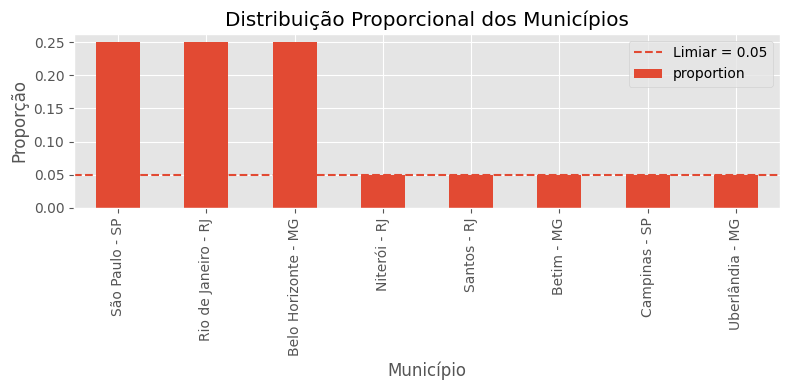

In [10]:
# 4a. EXPLORE a distribuição de Municipio (obrigatório antes de definir o limiar)
# Plote um gráfico de barras com as proporções e adicione uma linha horizontal
# no limiar que você pretende usar.

freq_municipios = df['Municipio'].value_counts(normalize=True)

# --- SEU GRÁFICO AQUI ---
limiar = 0.05

fig, ax = plt.subplots(figsize=(8,4))
freq_municipios.plot(kind='bar', ax=ax)
ax.axhline(y=limiar, linestyle='--', label=f'Limiar = {limiar}')
ax.set_title('Distribuição Proporcional dos Municípios')
ax.set_ylabel('Proporção')
ax.set_xlabel('Município')
ax.legend()
plt.tight_layout()
plt.show()

### 📝 Justificativa do Limiar (obrigatório)

> Com base no gráfico acima, defina o limiar que você vai usar e justifique:
>
> **Limiar escolhido:** [ex: 10%]
>
> **Justificativa:** [Por que este corte faz sentido analítico para esta base?  
> Quais municípios ficam de fora e isso é aceitável?]
>
> **Resposta:** O grafico apresenta que tres cidades concentram a maior parte das observaçoes, logo definir em 5% reduz a fragmentacao sem perder a informacao relevante, uma vez que os outros municipios aparecem em pequenos fragmentos.

In [11]:
# 4b. APLIQUE a redução de cardinalidade com o limiar que você justificou acima
meu_limiar = 0.05  # substitua pelo valor que você escolheu (ex: 0.10)

# municipios_para_agrupar = ...
# df.loc[...] = 'Outros'
municipios_para_agrupar = freq_municipios[freq_municipios < meu_limiar].index
df.loc[df['Municipio'].isin(municipios_para_agrupar), 'Municipio'] = 'Outros'

print(f"Municípios únicos antes: {freq_municipios.shape[0]}")
print(f"Municípios únicos depois: {df['Municipio'].nunique()}")

Municípios únicos antes: 8
Municípios únicos depois: 8


In [ ]:
# 5. Análise agrupada — Média Salarial por Município limpo
# Use groupby + mean e ordene do maior para o menor
media_salario_municipio = (
    df.groupby('Municipio')['Salario']
    .mean()
    .sort_values(ascending=False)
)

print(media_salario_municipio)

### 💬 Reflexão Final

> 1. O município `'Outros'` ficou com salário médio acima ou abaixo dos municípios individuais? O que isso pode significar?
> 2. Se você fosse apresentar este resultado para um gestor de RH, o que você **não** poderia afirmar com base apenas nesta análise?
> 3. O que aconteceria na prática se você rodasse `pd.get_dummies()` sobre `Municipio` **sem** ter feito a redução de cardinalidade?
>
> Suas respostas: Outros apresentou um salario médio diferente dos municipios individuais principais. Isso significa que o resultado representa apenas uma media  dessas cidades menores e nao permite identificar o comportamento salarial especifico de outros municipios.

---

**🎓 Parabéns por concluir o Lab 06!**  
No próximo laboratório (`lab_07_encoders.ipynb`), aplicaremos `pd.get_dummies()` sobre este DataFrame já limpo. Você verá exatamente por que o pré-processamento de hoje era indispensável.